# Report Visualisations — River Flood Hazard and Risk (Oblast Level)
Loads cached outputs from the GLOFAS hazard and Huizinga risk notebooks.
Place this script in the same directory as those notebooks and run after both.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
import contextily as ctx
import warnings

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

In [2]:
# ---------------------------------------------------------------------------
# Configuration — must match hazard and risk notebooks
# ---------------------------------------------------------------------------
SHAPEFILE_PATH  = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  # <-- update to your local shapefile path
OBLAST_FIELD    = 'oblast_en'
selected_oblast = 'North Kazakhstan Region'   # or None for full Kazakhstan
region_name     = 'NorthKazakhstanRegion'     # must match notebook outputs
return_periods  = [10, 50, 100, 200, 500]
return_period_aq = 250
scenarios        = ['rcp4p5', 'rcp8p5']
years_aq         = [2030, 2050, 2080]

In [3]:
# ---------------------------------------------------------------------------
# Paths — relative to this script (same folder as hazard notebook)
# ---------------------------------------------------------------------------
hazard_data_dir  = Path('.') / f'data_{region_name}'
aq_dir           = hazard_data_dir / 'aqueduct_floods'
risk_dir         = Path('.') / 'FLOOD_RIVER_risk'
risk_data_dir    = risk_dir / f'data_{region_name}'
risk_results_dir = risk_dir / f'results_{region_name}'
tif_dir          = risk_data_dir / 'floodmaps_resampled'
report_dir       = Path('.') / f'report_{region_name}'
report_dir.mkdir(exist_ok=True)

In [4]:
# ---------------------------------------------------------------------------
# Load cached data
# ---------------------------------------------------------------------------
kaz = gpd.read_file(SHAPEFILE_PATH)
region_gdf = (
    kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    if selected_oblast
    else gpd.GeoDataFrame(geometry=[kaz.geometry.union_all()], crs=kaz.crs)
)

floodmaps  = xr.open_dataset(
    hazard_data_dir / f'floodmaps_all_GLOFAS_PresentScenario_{region_name}.nc')
aq_base    = xr.open_dataset(
    aq_dir / f'inunriver_historical_000000000WATCH_1980_rp{return_period_aq:05}_{region_name}.nc')
aq_all     = xr.open_dataset(
    aq_dir / f'inunriver_AllScenarios_AllModels_AllYears_rp{return_period_aq:05}_{region_name}.nc')
dmg_csv    = pd.read_csv(
    risk_results_dir / f'damage_by_class_{region_name}.csv', index_col=0)

step         = max(1, int(500 / 90))    # downsample 90 m raster to ~500 m for plotting
scen_labels  = {'rcp4p5': 'RCP4.5', 'rcp8p5': 'RCP8.5'}
scen_colors  = {'rcp4p5': 'steelblue', 'rcp8p5': 'firebrick'}
ESA_LABELS   = {10: 'Tree cover', 20: 'Shrubland', 30: 'Grassland',
                40: 'Cropland',   50: 'Built-up',  60: 'Bare/sparse veg.',
                80: 'Perm. water', 90: 'Herbaceous wetland', 95: 'Mangroves'}

print(f'Data loaded. Reports will be saved to: {report_dir}')

Data loaded. Reports will be saved to: report_NorthKazakhstanRegion


# Flood Hazard — Present-Day Inundation Depth

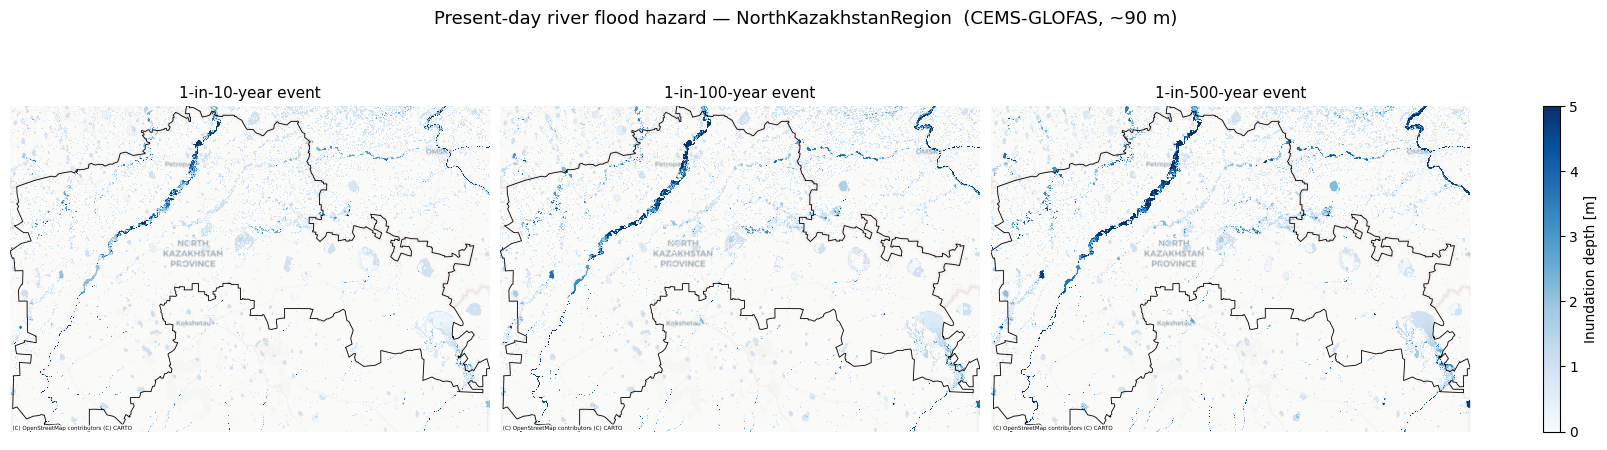

In [5]:
rps_plot = [10, 100, 500]
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                        sharex=True, sharey=True)
for ii, rp in enumerate(rps_plot):
    da = floodmaps[f'RP{rp}'].isel(x=slice(None, None, step),
                                    y=slice(None, None, step))
    bs = da.plot(ax=axs[ii], cmap='Blues', vmin=0, vmax=5, add_colorbar=False)
    region_gdf.boundary.plot(ax=axs[ii], color='black', linewidth=0.6)
    ctx.add_basemap(axs[ii], crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'1-in-{rp}-year event', fontsize=11)
    axs[ii].set_axis_off()
fig.colorbar(bs, ax=axs.ravel().tolist(), label='Inundation depth [m]', shrink=0.7)
fig.suptitle(f'Present-day river flood hazard — {region_name}  (CEMS-GLOFAS, ~90 m)', fontsize=13)
fig.savefig(report_dir / 'fig01_hazard_present.png', dpi=150, bbox_inches='tight')
plt.show()

# Flood Depth Distribution by Return Period

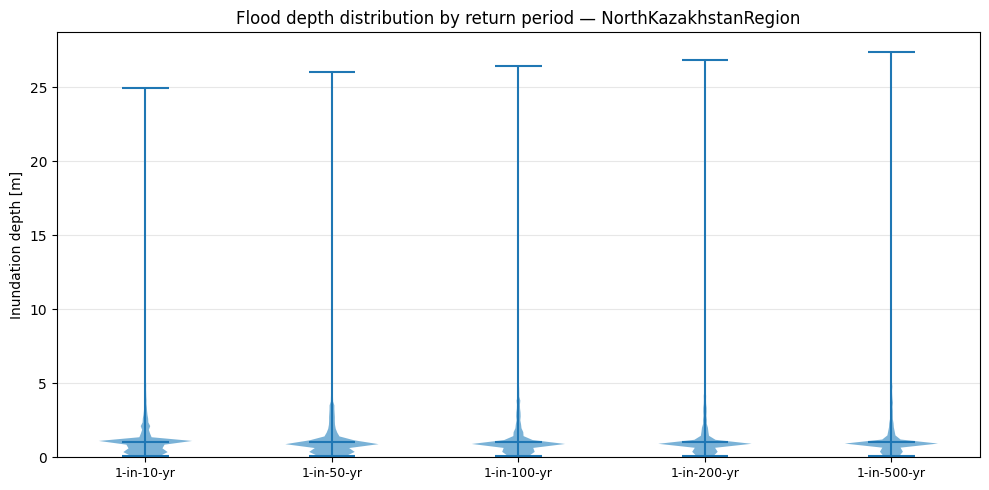

In [6]:
depth_data = []
for rp in return_periods:
    vals = floodmaps[f'RP{rp}'].values.flatten()
    wet  = vals[np.isfinite(vals) & (vals > 0)]
    depth_data.append(wet if len(wet) else np.array([0.0]))

fig, ax = plt.subplots(figsize=(10, 5))
vp = ax.violinplot(depth_data, showmedians=True)
for pc in vp['bodies']:
    pc.set_facecolor('#4292c6')
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(return_periods) + 1))
ax.set_xticklabels([f'1-in-{rp}-yr' for rp in return_periods], fontsize=9)
ax.set_ylabel('Inundation depth [m]')
ax.set_title(f'Flood depth distribution by return period — {region_name}')
ax.set_ylim(0)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig02_depth_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Flooded Area by Return Period

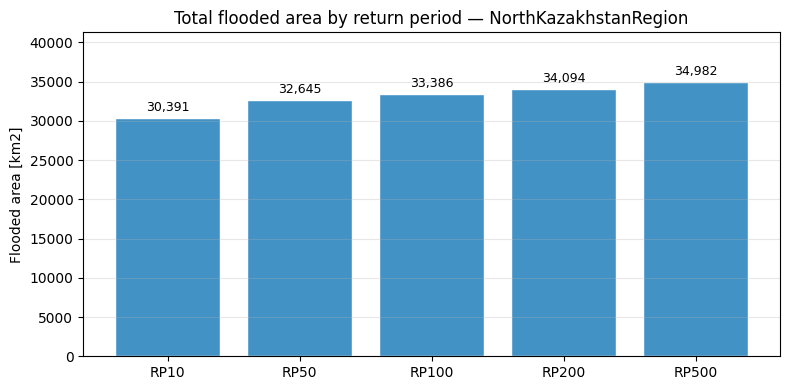

In [7]:
res_deg    = abs(float(floodmaps.x[1] - floodmaps.x[0]))
pixel_km2  = (res_deg * 111.32) ** 2
flooded_km2 = [
    int(np.sum(np.isfinite(floodmaps[f'RP{rp}'].values)
               & (floodmaps[f'RP{rp}'].values > 0))) * pixel_km2
    for rp in return_periods
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'RP{rp}' for rp in return_periods], flooded_km2,
              color='#4292c6', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in flooded_km2], padding=3, fontsize=9)
ax.set_ylabel('Flooded area [km2]')
ax.set_title(f'Total flooded area by return period — {region_name}')
ax.set_ylim(0, max(flooded_km2) * 1.18)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig03_flooded_area.png', dpi=150, bbox_inches='tight')
plt.show()

# Projected Flood Depth Change — RCP8.5

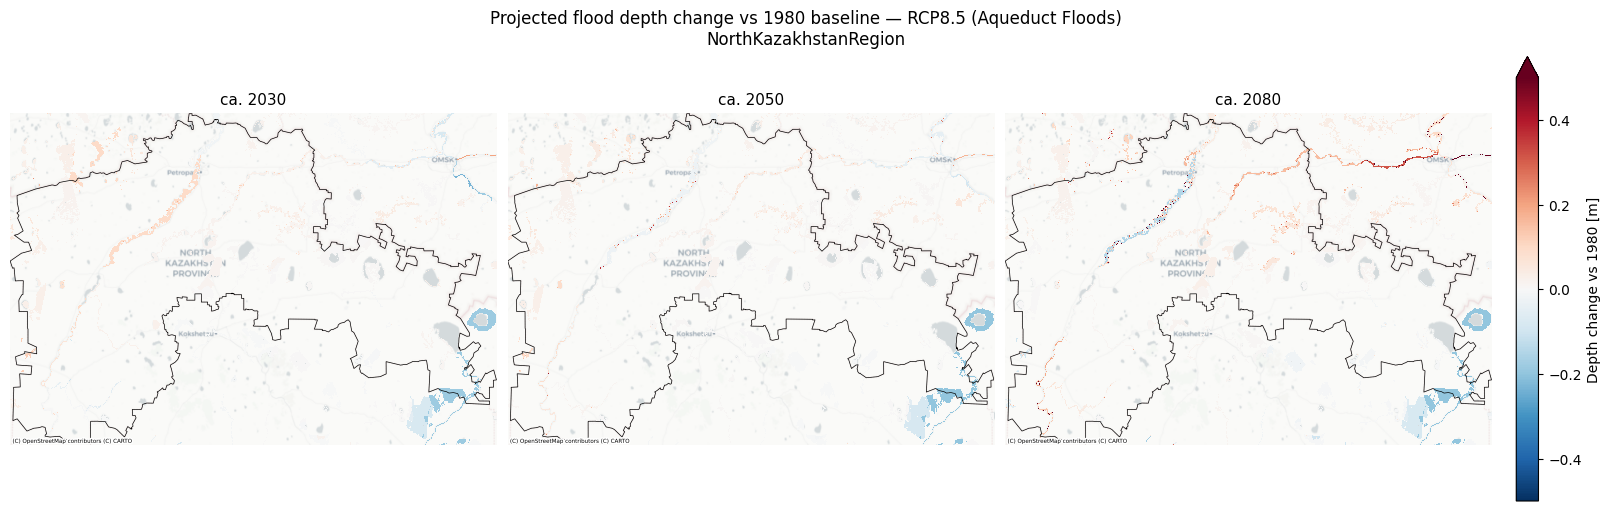

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                        sharex=True, sharey=True)
for ii, year in enumerate(years_aq):
    diff = (aq_all['inun'].sel(year=year, scenario='rcp8p5').squeeze()
            - aq_base['inun'].squeeze())
    last = ii == 2
    diff.plot(ax=axs[ii], cmap='RdBu_r', vmin=-0.5, vmax=0.5,
              add_colorbar=last,
              cbar_kwargs={'label': 'Depth change vs 1980 [m]'} if last else {})
    region_gdf.boundary.plot(ax=axs[ii], color='black', linewidth=0.5)
    ctx.add_basemap(axs[ii], crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'ca. {year}', fontsize=11)
    axs[ii].set_axis_off()
fig.suptitle(
    f'Projected flood depth change vs 1980 baseline — RCP8.5 (Aqueduct Floods)\n{region_name}',
    fontsize=12)
fig.savefig(report_dir / 'fig04_projected_change_rcp85.png', dpi=150, bbox_inches='tight')
plt.show()

# Scenario Comparison — Projected Mean Depth Change

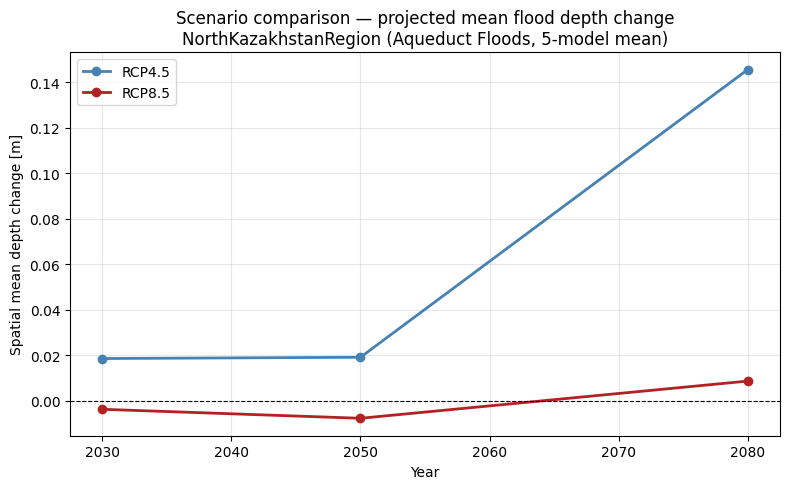

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for scen in scenarios:
    diffs = [
        float((aq_all['inun'].sel(year=y, scenario=scen).squeeze()
               - aq_base['inun'].squeeze()).mean(skipna=True))
        for y in years_aq
    ]
    ax.plot(years_aq, diffs, marker='o', label=scen_labels[scen],
            color=scen_colors[scen], linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Spatial mean depth change [m]')
ax.set_title(
    f'Scenario comparison — projected mean flood depth change\n'
    f'{region_name} (Aqueduct Floods, 5-model mean)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig05_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ESA WorldCover Land Cover in RP100 Flood Zone

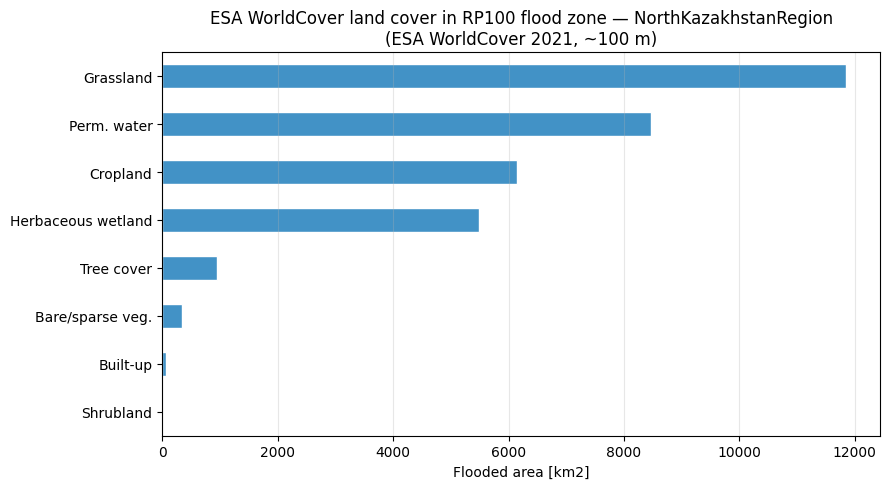

In [10]:
with rasterio.open(risk_data_dir / f'land_cover_ESA_WC_{region_name}.tif') as src:
    lc_arr = src.read(1).astype(float)
with rasterio.open(tif_dir / f'floodmap_resampled_{region_name}_RP100.tif') as src:
    fm_arr = src.read(1).astype(float)
fm_arr[fm_arr <= 0] = np.nan
flooded = np.isfinite(fm_arr)

class_km2 = {
    ESA_LABELS[c]: float(np.sum(flooded & (lc_arr == c))) * 0.01
    for c in ESA_LABELS
    if np.sum(flooded & (lc_arr == c)) > 0
}
df_lc = pd.Series(class_km2).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
df_lc.plot.barh(ax=ax, color='#4292c6', edgecolor='white')
ax.set_xlabel('Flooded area [km2]')
ax.set_title(
    f'ESA WorldCover land cover in RP100 flood zone — {region_name}\n'
    '(ESA WorldCover 2021, ~100 m)')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig06_landcover_flood_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Economic Damage Maps — Overview

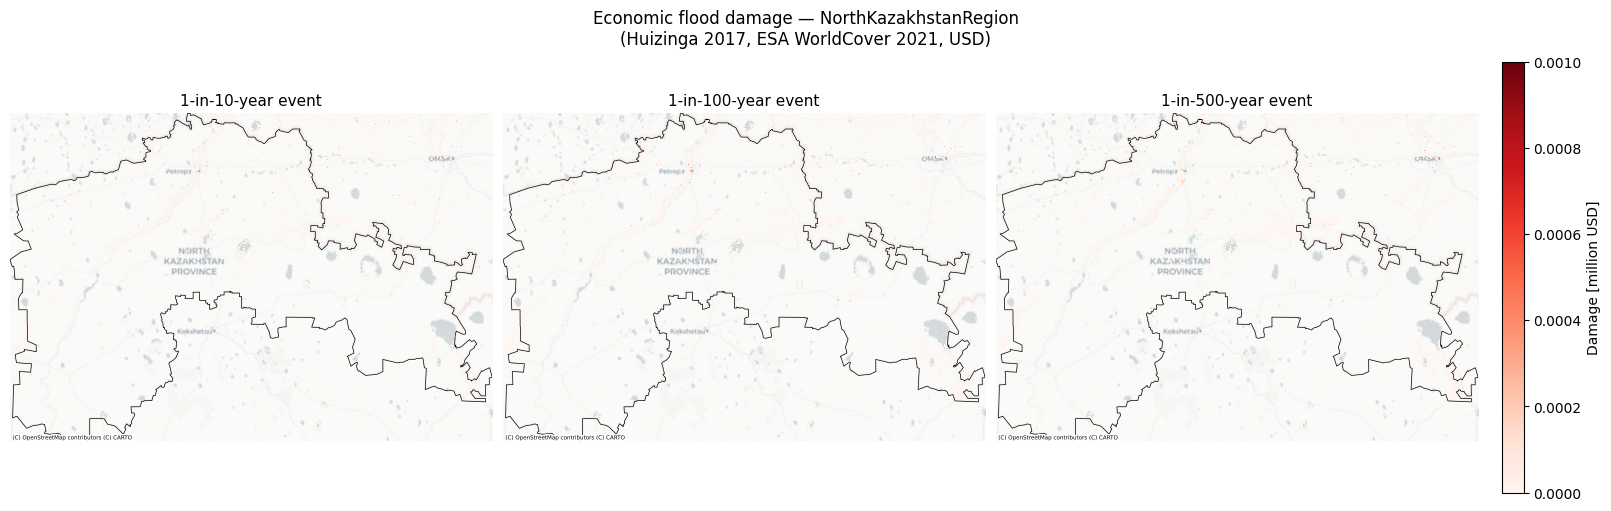

In [11]:
rps_plot   = [10, 100, 500]
dmg_arrays = {}
vmax_dmg   = 0
for rp in rps_plot:
    da = rxr.open_rasterio(
        risk_results_dir / f'flood_{region_name}_RP{rp}_damagemap.tif').squeeze()
    dmg_arrays[rp] = da.where(da > 0) / 1e6
    vmax_dmg = max(vmax_dmg, float(dmg_arrays[rp].max()))

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True,
                        sharex=True, sharey=True)
for ii, rp in enumerate(rps_plot):
    da   = dmg_arrays[rp].isel(x=slice(None, None, 3), y=slice(None, None, 3))
    last = ii == 2
    bs   = da.plot(ax=axs[ii], cmap='Reds', vmin=0, vmax=max(vmax_dmg, 0.001),
                   add_colorbar=last,
                   cbar_kwargs={'label': 'Damage [million USD]'} if last else {})
    region_gdf.boundary.plot(ax=axs[ii], color='black', linewidth=0.5)
    ctx.add_basemap(axs[ii], crs='EPSG:4326',
                    source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'1-in-{rp}-year event', fontsize=11)
    axs[ii].set_axis_off()
fig.suptitle(
    f'Economic flood damage — {region_name}\n'
    '(Huizinga 2017, ESA WorldCover 2021, USD)', fontsize=12)
fig.savefig(report_dir / 'fig07_damage_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Economic Damage by Land Cover Class

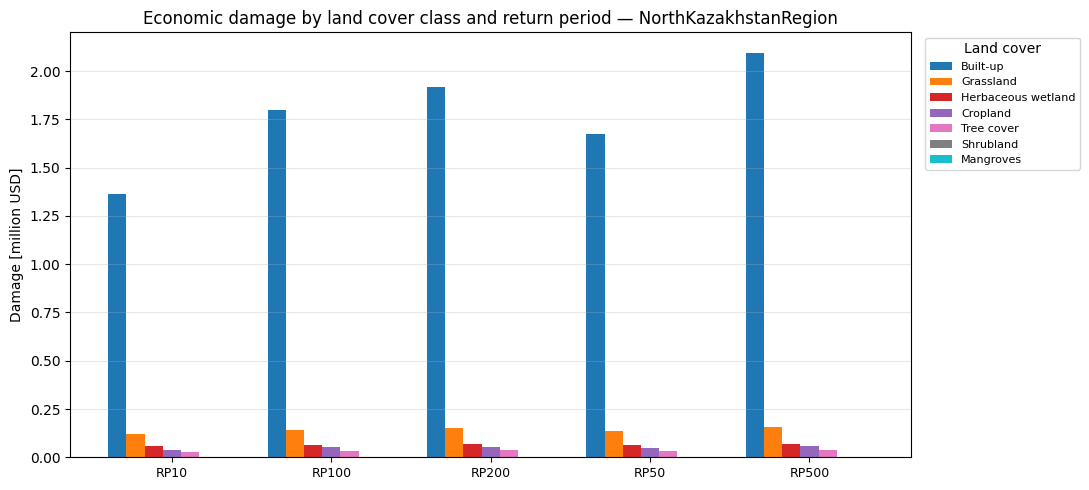

In [12]:
rp_cols    = [c for c in dmg_csv.columns if c.startswith('RP')]
lc_labels  = dmg_csv['Land cover'].values
dm_vals    = dmg_csv[rp_cols].values   # already in million USD
x          = np.arange(len(rp_cols))
width      = 0.8 / len(lc_labels)
colors     = plt.cm.tab10(np.linspace(0, 0.9, len(lc_labels)))

fig, ax = plt.subplots(figsize=(11, 5))
for i, (label, row) in enumerate(zip(lc_labels, dm_vals)):
    ax.bar(x + i * width - 0.4 + width / 2, row, width,
           label=label, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(rp_cols, fontsize=9)
ax.set_ylabel('Damage [million USD]')
ax.set_title(f'Economic damage by land cover class and return period — {region_name}')
ax.legend(title='Land cover', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig08_damage_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Damage-Exceedance Curve and Expected Annual Damage

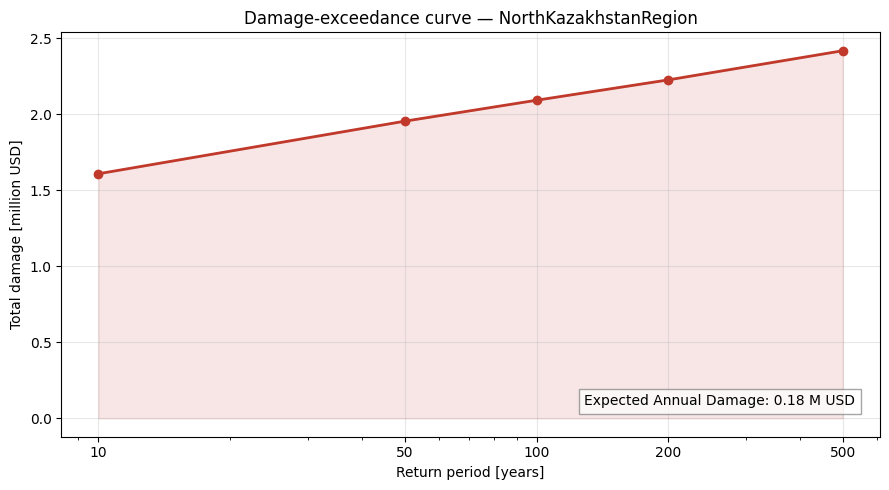

In [13]:
total_mUSD = []
for rp in return_periods:
    with rasterio.open(
            risk_results_dir / f'flood_{region_name}_RP{rp}_damagemap.tif') as src:
        arr = src.read(1).astype(float)
    total_mUSD.append(float(np.nansum(arr[arr > 0])) / 1e6)

probs  = 1 / np.array(return_periods, dtype=float)
totals = np.array(total_mUSD)
ead    = float(sum(
    (probs[i] - probs[i + 1]) * (totals[i] + totals[i + 1]) / 2
    for i in range(len(return_periods) - 1)
))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(return_periods, totals, marker='o', color='#c0392b', linewidth=2)
ax.fill_between(return_periods, 0, totals, alpha=0.12, color='#c0392b')
ax.set_xscale('log')
ax.set_xticks(return_periods)
ax.set_xticklabels(return_periods)
ax.set_xlabel('Return period [years]')
ax.set_ylabel('Total damage [million USD]')
ax.set_title(f'Damage-exceedance curve — {region_name}')
ax.text(0.97, 0.07, f'Expected Annual Damage: {ead:.2f} M USD',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(report_dir / 'fig09_damage_exceedance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary Infographic Panel

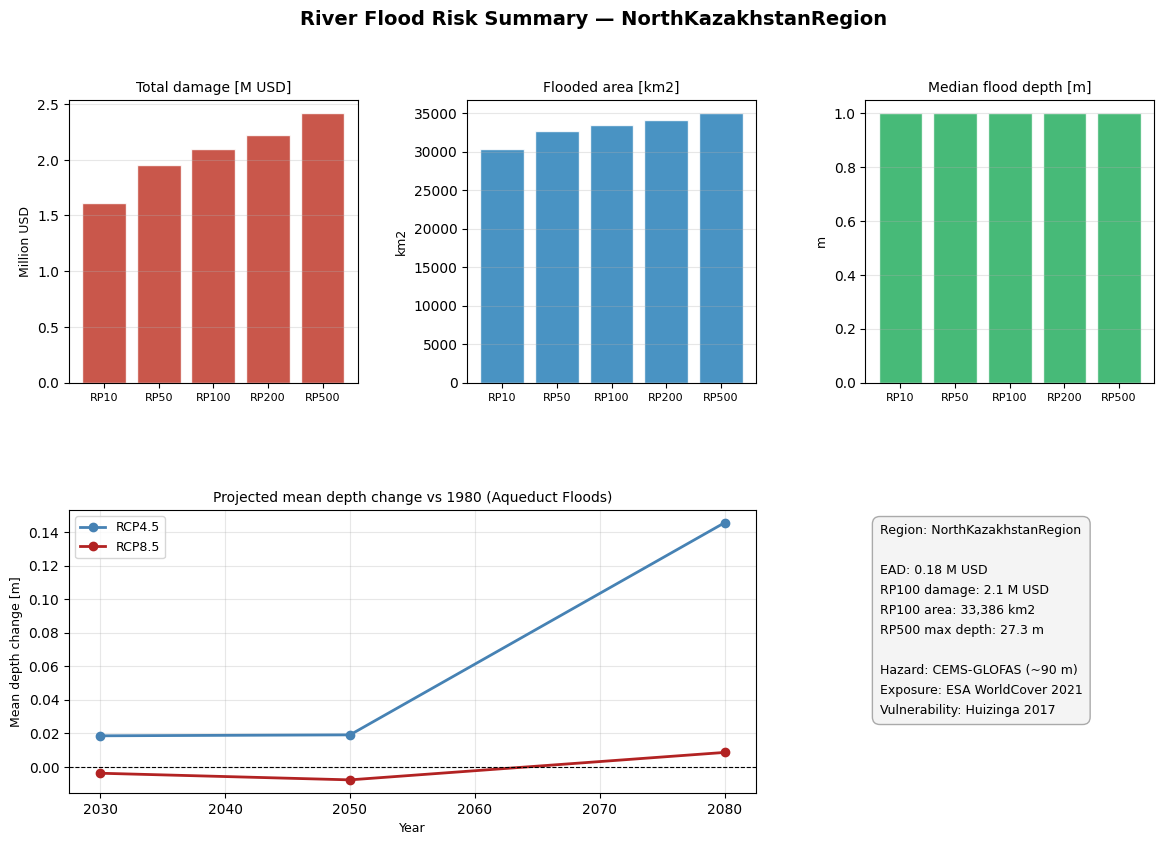

All report figures saved to: report_NorthKazakhstanRegion


In [14]:
median_depths = []
for rp in return_periods:
    vals = floodmaps[f'RP{rp}'].values.flatten()
    wet  = vals[np.isfinite(vals) & (vals > 0)]
    median_depths.append(float(np.median(wet)) if len(wet) else 0.0)

rp_labels  = [f'RP{rp}' for rp in return_periods]
rp100_idx  = return_periods.index(100)

fig = plt.figure(figsize=(14, 9))
gs  = mgs.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_a = fig.add_subplot(gs[0, 0])
ax_a.bar(rp_labels, totals, color='#c0392b', alpha=0.85, edgecolor='white')
ax_a.set_title('Total damage [M USD]', fontsize=10)
ax_a.set_ylabel('Million USD', fontsize=9)
ax_a.tick_params(axis='x', labelsize=8)
ax_a.grid(axis='y', alpha=0.3)

ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(rp_labels, flooded_km2, color='#2980b9', alpha=0.85, edgecolor='white')
ax_b.set_title('Flooded area [km2]', fontsize=10)
ax_b.set_ylabel('km2', fontsize=9)
ax_b.tick_params(axis='x', labelsize=8)
ax_b.grid(axis='y', alpha=0.3)

ax_c = fig.add_subplot(gs[0, 2])
ax_c.bar(rp_labels, median_depths, color='#27ae60', alpha=0.85, edgecolor='white')
ax_c.set_title('Median flood depth [m]', fontsize=10)
ax_c.set_ylabel('m', fontsize=9)
ax_c.tick_params(axis='x', labelsize=8)
ax_c.grid(axis='y', alpha=0.3)

ax_d = fig.add_subplot(gs[1, :2])
for scen in scenarios:
    diffs = [
        float((aq_all['inun'].sel(year=y, scenario=scen).squeeze()
               - aq_base['inun'].squeeze()).mean(skipna=True))
        for y in years_aq
    ]
    ax_d.plot(years_aq, diffs, marker='o', label=scen_labels[scen],
              color=scen_colors[scen], linewidth=2)
ax_d.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_d.set_xlabel('Year', fontsize=9)
ax_d.set_ylabel('Mean depth change [m]', fontsize=9)
ax_d.set_title('Projected mean depth change vs 1980 (Aqueduct Floods)', fontsize=10)
ax_d.legend(fontsize=9)
ax_d.grid(alpha=0.3)

ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')
stats_lines = [
    f'Region: {region_name}',
    '',
    f'EAD: {ead:.2f} M USD',
    f'RP100 damage: {totals[rp100_idx]:.1f} M USD',
    f'RP100 area: {flooded_km2[rp100_idx]:,.0f} km2',
    f'RP500 max depth: {float(floodmaps["RP500"].max()):.1f} m',
    '',
    'Hazard: CEMS-GLOFAS (~90 m)',
    'Exposure: ESA WorldCover 2021',
    'Vulnerability: Huizinga 2017',
]
ax_e.text(0.05, 0.95, '\n'.join(stats_lines), transform=ax_e.transAxes,
          va='top', fontsize=9, linespacing=1.7,
          bbox=dict(facecolor='#f4f4f4', edgecolor='#aaaaaa', boxstyle='round,pad=0.6'))

fig.suptitle(f'River Flood Risk Summary — {region_name}',
             fontsize=14, fontweight='bold')
fig.savefig(report_dir / 'fig10_summary_infographic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'All report figures saved to: {report_dir}')